# **1. Entendimiento del problema**

# **2. Enfoque analítico**

# **3. Requerimiento de datos**

# **4. Recolección de datos**

In [1]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [2]:
data = fetch_dataset('fuel_consumption')
data.index.name = 'gasoleos'

╭──────────────────────────────── fuel_consumption ────────────────────────────────╮
│ Description:                                                                     │
│ Monthly fuel consumption in Spain from 1969-01-01 to 2022-08-01.                 │
│                                                                                  │
│ Source:                                                                          │
│ Obtained from Corporación de Reservas Estratégicas de Productos Petrolíferos and │
│ Corporación de Derecho Público tutelada por el Ministerio para la Transición     │
│ Ecológica y el Reto Demográfico. https://www.cores.es/es/estadisticas            │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/consumos-combustibles-mensual.csv                             │
│                                                                                  │
│ Shape: 644 rows x 5 columns                                                      │
╰──────────────────────────────────────────────────────────────────────────────────╯

In [3]:
data

,GLPs,Gasolinas,Querosenos,Gasoleos,Fueloleos
gasoleos,,,,,
1969-01-01,133615.09620,166875.2129,123257.8090,4.011853e+05,912583.4202
1969-02-01,126748.47410,155466.8105,114682.5767,3.853600e+05,851877.8115
1969-03-01,107795.80910,184983.6699,109970.0796,4.189556e+05,873884.2933
1969-04-01,96683.15967,202319.8164,108797.9255,4.389755e+05,755490.1170
1969-05-01,79506.23804,206259.1523,103554.0784,4.674519e+05,729963.6009
...,...,...,...,...,...
2022-04-01,179591.64000,471601.9400,494966.3200,2.638030e+06,636930.4200
2022-05-01,134166.56000,478873.4100,530034.0100,2.673797e+06,708289.2600
2022-06-01,142480.09000,501447.1400,540594.9700,2.648087e+06,667221.4500


# **5. Exploración de Datos**

- Identificar los patrones estacionales de la serie
- Determinar la estacionariedad de la serie

In [4]:
from skforecast.plot import set_dark_theme
set_dark_theme()

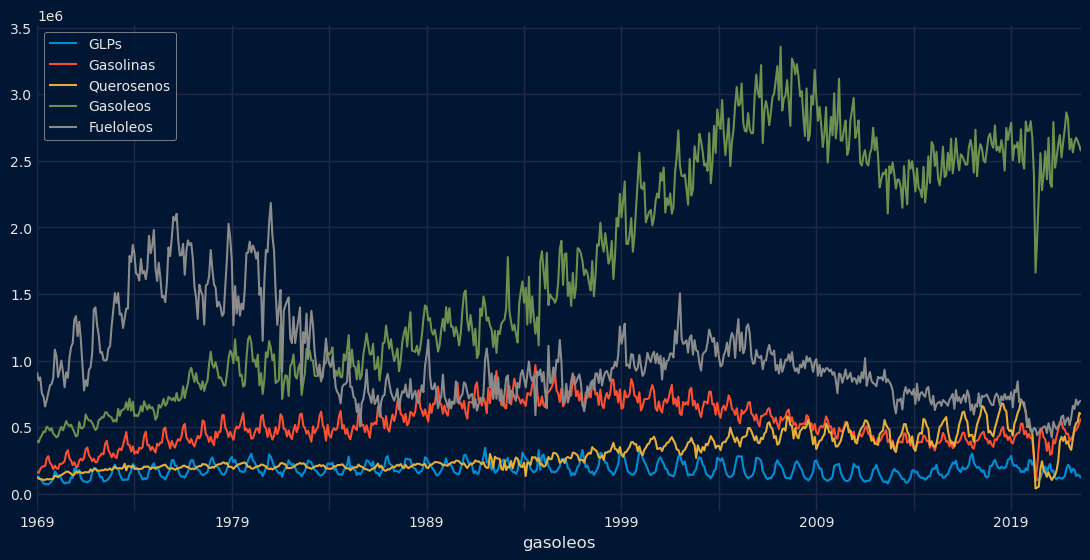

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
data.plot(ax=ax)
ax.legend()
plt.show()

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

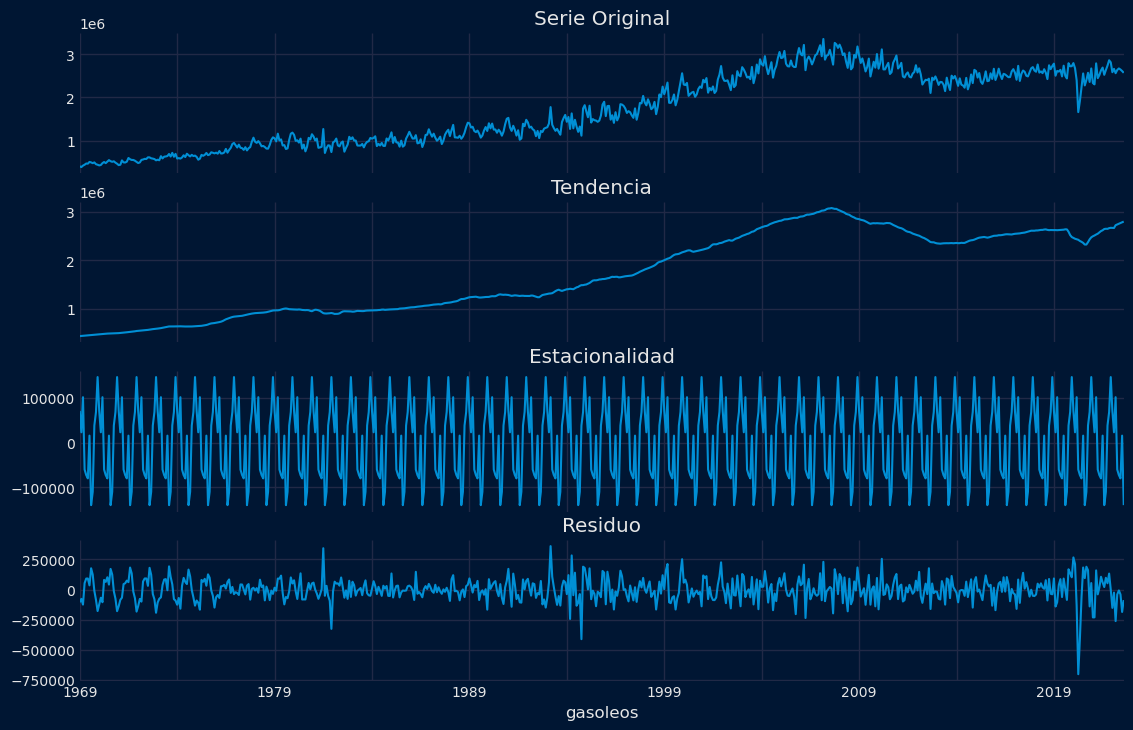

In [8]:
res_decompose = seasonal_decompose(data['Gasoleos'], model='additive', extrapolate_trend='freq') # additive o multiplicative
fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
res_decompose.observed.plot(ax=ax[0])
ax[0].set_title('Serie Original')
res_decompose.trend.plot(ax=ax[1])
ax[1].set_title('Tendencia')
res_decompose.seasonal.plot(ax=ax[2])
ax[2].set_title('Estacionalidad')
res_decompose.resid.plot(ax=ax[3])
ax[3].set_title('Residuo')
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller

In [14]:
print('Test Estacionariedad de Dickey-Fuller Aumentado')
result = adfuller(data['Gasoleos'])
print('ADF Estadístico:', result[0])
print('Valor p:', result[1])

Test Estacionariedad de Dickey-Fuller Aumentado
ADF Estadístico: -1.11778863076028
Valor p: 0.7079261245070301


# **6. Preparación de los Datos**

- Diferenciar la serie
- Identificar su comportamiento estacional

Test Estacionariedad de Dickey-Fuller Aumentado
ADF Estadístico: -4.9039221015161845
Valor p: 3.426647001260671e-05


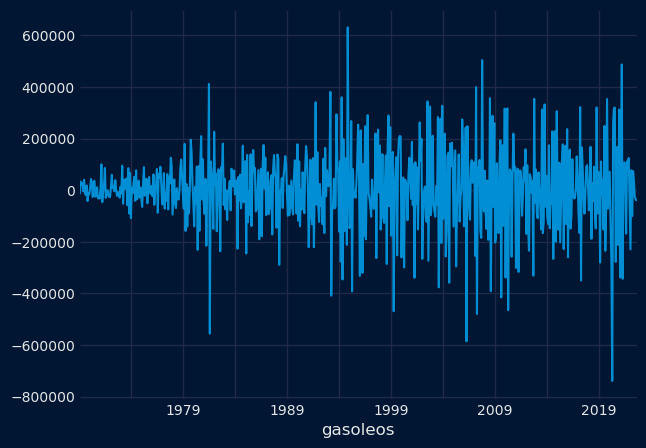

In [15]:
data_diff = data['Gasoleos'].diff().dropna()
print('Test Estacionariedad de Dickey-Fuller Aumentado')
result = adfuller(data_diff)
print('ADF Estadístico:', result[0])
print('Valor p:', result[1])
data_diff.plot()
plt.show()

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

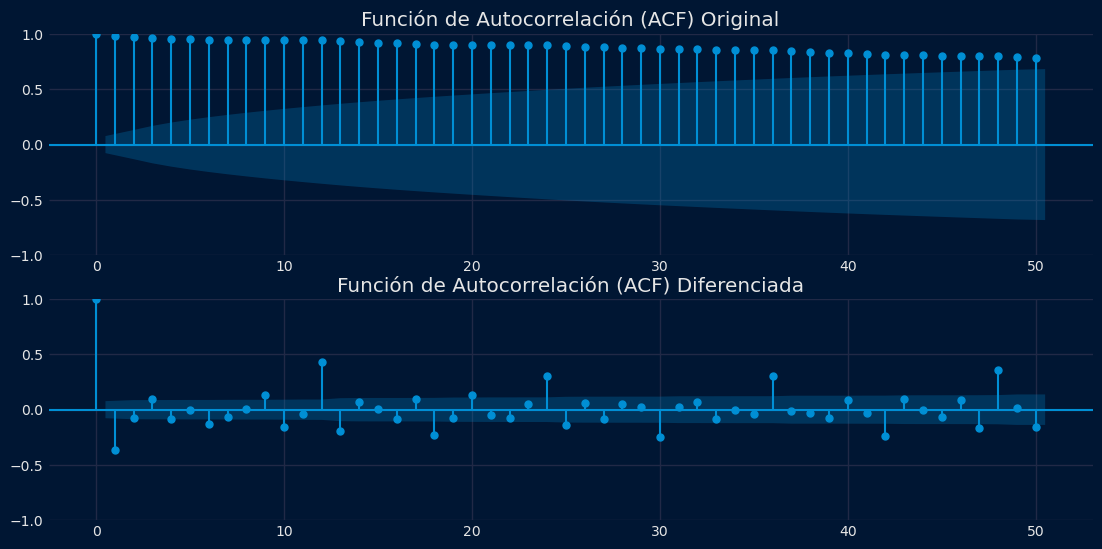

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(data['Gasoleos'], lags=50, ax=ax[0], alpha=0.05)
ax[0].set_title('Función de Autocorrelación (ACF) Original')
plot_acf(data_diff, lags=50, ax=ax[1], alpha=0.05)
ax[1].set_title('Función de Autocorrelación (ACF) Diferenciada')
plt.show()

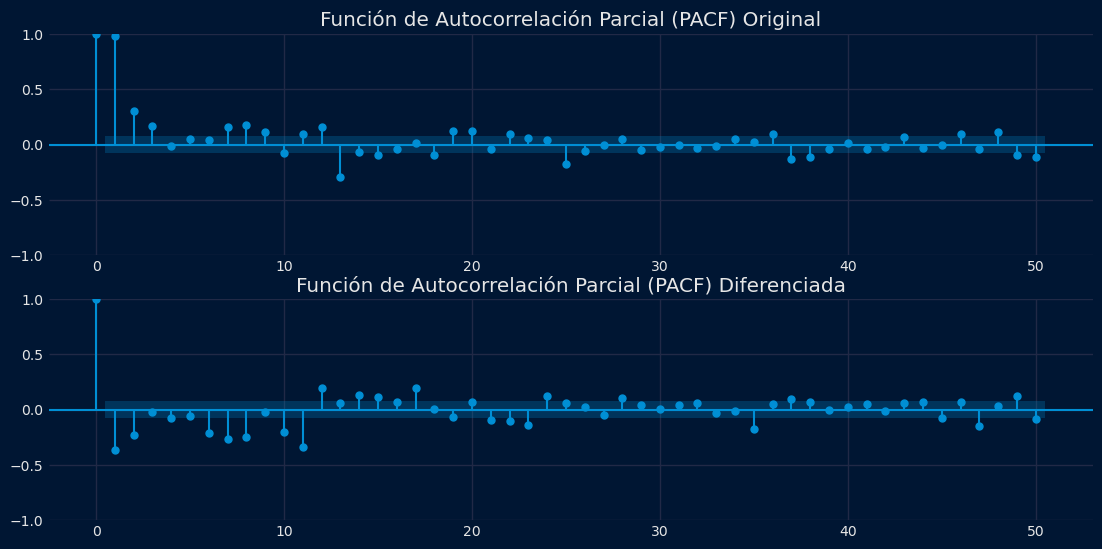

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6))
plot_pacf(data['Gasoleos'], lags=50, ax=ax[0], alpha=0.05)
ax[0].set_title('Función de Autocorrelación Parcial (PACF) Original')
plot_pacf(data_diff, lags=50, ax=ax[1], alpha=0.05)
ax[1].set_title('Función de Autocorrelación Parcial (PACF) Diferenciada')
plt.show()